In [3]:
# Imports and configuration

import os
import re
import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor


@dataclass
class Config:
    csv_path: str = "TI_MOR_20160101_20221231_dataset_final.csv"
    date_col_candidates: Tuple[str, ...] = ("date", "Date", "datetime", "Datetime", "time", "Time", "timestamp", "Timestamp")

    days_ahead: Tuple[int, ...] = (1, 2, 3, 4, 5, 6)

    test_days: int = 365
    cv_splits: int = 5
    random_state: int = 42

    quantiles_for_average: Tuple[float, ...] = (0.1, 0.5, 0.9)
    output_csv: str = "pm10_final_challenge_forecasts.csv"


In [4]:
# Small helpers used everywhere

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def safe_eval_mae_rmse(y_true: pd.Series, y_pred: np.ndarray) -> Tuple[float, float, int]:
    yt = y_true.to_numpy(dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(yt) & np.isfinite(yp)
    n = int(mask.sum())
    if n == 0:
        return float("nan"), float("nan"), 0
    return float(mean_absolute_error(yt[mask], yp[mask])), rmse(yt[mask], yp[mask]), n


def find_datetime_column(df: pd.DataFrame, candidates: Tuple[str, ...]) -> Optional[str]:
    for c in candidates:
        if c in df.columns:
            return c
    for c in df.columns:
        s = str(c).lower()
        if "date" in s or "time" in s:
            return c
    return None


def enforce_monotonic_quantiles(preds: Dict[float, np.ndarray]) -> Dict[float, np.ndarray]:
    qs = sorted(preds.keys())
    stacked = np.vstack([preds[q] for q in qs]).astype(float)
    stacked = np.maximum.accumulate(stacked, axis=0)
    return {q: stacked[i, :] for i, q in enumerate(qs)}


In [5]:
# Load the CSV and make sure the index is a clean daily datetime index

def load_pm10_dataset(cfg: Config) -> pd.DataFrame:
    if not os.path.exists(cfg.csv_path):
        raise FileNotFoundError(f"CSV file not found: {cfg.csv_path}")

    df = pd.read_csv(cfg.csv_path)

    dt_col = find_datetime_column(df, cfg.date_col_candidates)
    if dt_col is None:
        raise ValueError("No datetime column found in the dataset.")

    df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce")
    df = df.dropna(subset=[dt_col])
    df = df.sort_values(dt_col).set_index(dt_col)

    df.index = pd.to_datetime(df.index)
    df = df[~df.index.duplicated(keep="first")]

    if df.index.inferred_freq is None:
        df = df.asfreq("D")

    return df


In [6]:
# Detect the PM10 targets per location and horizon.
# This dataset uses d0..d5. We map days ahead 1..6 to dataset d0..d5.

def detect_targets_d(df: pd.DataFrame) -> Dict[Tuple[str, int], str]:
    targets: Dict[Tuple[str, int], str] = {}
    pattern = re.compile(r"^(?P<loc>.+)__YPM10-dailymean__d(?P<d>\d+)$")

    for col in df.columns:
        m = pattern.match(str(col))
        if m:
            loc = m.group("loc")
            d = int(m.group("d"))
            targets[(loc, d)] = str(col)

    if len(targets) == 0:
        raise ValueError("No PM10 targets found matching LOC__YPM10-dailymean__dX")

    return targets


def list_locations_from_targets(target_map: Dict[Tuple[str, int], str]) -> List[str]:
    return sorted({loc for (loc, _) in target_map.keys()})


def build_horizon_map(days_ahead: Tuple[int, ...]) -> Dict[int, int]:
    mapping = {k: k - 1 for k in days_ahead}
    return mapping


Horizon definition note
The dataset encodes six forecasting horizons as d0 to d5.
In this notebook, we report results as 1 to 6 days ahead using the mapping day_ahead = d + 1.

In [7]:
# Models and preprocessing

def make_preprocess(X_train: pd.DataFrame) -> ColumnTransformer:
    numeric_cols = list(X_train.columns)
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_cols)
        ],
        remainder="drop"
    )


def point_model(random_state: int) -> HistGradientBoostingRegressor:
    return HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.05,
        max_depth=6,
        max_leaf_nodes=63,
        min_samples_leaf=25,
        random_state=random_state
    )


def quantile_model(q: float, random_state: int) -> HistGradientBoostingRegressor:
    return HistGradientBoostingRegressor(
        loss="quantile",
        quantile=q,
        learning_rate=0.05,
        max_depth=6,
        max_leaf_nodes=63,
        min_samples_leaf=25,
        random_state=random_state
    )


def fit_predict(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, model) -> np.ndarray:
    pipe = Pipeline([
        ("pre", make_preprocess(X_train)),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    return pipe.predict(X_test)


In [ ]:
# Time series split and cross validation

def split_train_test_time_series(X: pd.DataFrame, y: pd.Series, test_days: int):
    valid = y.notna()
    Xv, yv = X.loc[valid], y.loc[valid]

    if len(yv) <= test_days + 60:
        raise ValueError("Not enough samples for test_days. Reduce cfg.test_days.")

    split = len(yv) - test_days
    return Xv.iloc[:split], Xv.iloc[split:], yv.iloc[:split], yv.iloc[split:]



In [ ]:
# Naive baselines computed from observed PM10 measurements (hourly columns)
# This matches the dataset naming convention on the challenge page:
# LOCATION__SIGNAL__HOUR for measurements, and DAY_AHEAD for targets.
# We build a daily observed PM10 mean from the 24 hourly PM10 columns, then:
# naive persistence = observed daily mean at time t
# naive seasonal7 = observed daily mean at time t-7

def observed_pm10_dailymean_from_hours(df: pd.DataFrame, loc: str) -> Optional[pd.Series]:
    hour_cols = [c for c in df.columns if re.fullmatch(rf"{re.escape(loc)}__PM10__m\d+", str(c))]
    if len(hour_cols) == 0:
        return None

    def hour_index(colname: str) -> int:
        m = re.search(r"__m(\d+)$", str(colname))
        return int(m.group(1)) if m else 999

    hour_cols = sorted(hour_cols, key=hour_index)

    pm10_hours = df[hour_cols].apply(pd.to_numeric, errors="coerce")
    daily_mean = pm10_hours.mean(axis=1)

    return daily_mean


def naive_persistence(df: pd.DataFrame, loc: str) -> Optional[pd.Series]:
    return observed_pm10_dailymean_from_hours(df, loc)


def naive_seasonal7(df: pd.DataFrame, loc: str) -> Optional[pd.Series]:
    base = observed_pm10_dailymean_from_hours(df, loc)
    if base is None:
        return None
    return base.shift(7)

In [ ]:
# Main pipeline:
# 1) Train point models for every location and day ahead
# 2) Train quantile models for the average for probabilistic forecast
# 3) Compute naive baseline MAE using d0 persistence and d0 seasonal 7 day persistence

def main(cfg: Config):
    df = load_pm10_dataset(cfg)

    target_map = detect_targets_d(df)
    locations = list_locations_from_targets(target_map)
    horizon_map = build_horizon_map(cfg.days_ahead)

    missing = []
    for loc in locations:
        for k in cfg.days_ahead:
            d = horizon_map[k]
            if (loc, d) not in target_map:
                missing.append((loc, k, d))
    if len(missing) > 0:
        loc, k, d = missing[0]
        raise ValueError(f"Missing target column for {loc} days ahead {k} expected dataset d{d}")

    all_target_cols = [target_map[(loc, horizon_map[k])] for loc in locations for k in cfg.days_ahead]
    X_all = df.drop(columns=all_target_cols, errors="ignore").replace([np.inf, -np.inf], np.nan)

    forecasts = pd.DataFrame(index=df.index)
    rows: List[Dict[str, object]] = []

    for k in cfg.days_ahead:
        d = horizon_map[k]
        station_series_for_avg: List[pd.Series] = []

        for loc in locations:
            y = pd.to_numeric(df[target_map[(loc, d)]], errors="coerce")
            X_train, X_test, y_train, y_test = split_train_test_time_series(X_all, y, cfg.test_days)

            #cv_val = cv_mae(X_train, y_train, cfg.cv_splits, cfg.random_state)
            pred = fit_predict(X_train, y_train, X_test, point_model(cfg.random_state))

            pred_col = f"{loc}__pred__d{k}"
            forecasts.loc[y_test.index, pred_col] = pred

            mae, r, n = safe_eval_mae_rmse(y_test, pred)

            #naive_p = naive_persistence_from_d0(df, loc, target_map)
            #naive_s = naive_seasonal7_from_d0(df, loc, target_map)
            naive_p = naive_persistence(df, loc)
            naive_s = naive_seasonal7(df, loc)

            naive_p_mae = float("nan")
            naive_s_mae = float("nan")

            if naive_p is not None:
                npred = naive_p.reindex(y_test.index).to_numpy(dtype=float)
                naive_p_mae, _, nn = safe_eval_mae_rmse(y_test, npred)
                if nn == 0:
                    naive_p_mae = float("nan")

            if naive_s is not None:
                spred = naive_s.reindex(y_test.index).to_numpy(dtype=float)
                naive_s_mae, _, nn = safe_eval_mae_rmse(y_test, spred)
                if nn == 0:
                    naive_s_mae = float("nan")

            best_naive = np.nan
            if np.isfinite(naive_p_mae) and np.isfinite(naive_s_mae):
                best_naive = float(min(naive_p_mae, naive_s_mae))
            elif np.isfinite(naive_p_mae):
                best_naive = float(naive_p_mae)
            elif np.isfinite(naive_s_mae):
                best_naive = float(naive_s_mae)

            rows.append({
            "location": loc,
            "horizon_days": k,
            "task": "point_forecast",
            "test_mae": mae,
            "test_rmse": r,
            "n_test": n,
            "naive_persistence_mae": naive_p_mae,
            "naive_seasonal7_mae": naive_s_mae,
            "best_naive_mae": best_naive,
            "beats_best_naive": (mae < best_naive) if np.isfinite(best_naive) else np.nan
        })


            station_series_for_avg.append(y)

        y_avg = pd.concat(station_series_for_avg, axis=1).mean(axis=1)
        X_train, X_test, y_train, y_test = split_train_test_time_series(X_all, y_avg, cfg.test_days)

        q_preds: Dict[float, np.ndarray] = {}
        for q in cfg.quantiles_for_average:
            q_preds[q] = fit_predict(X_train, y_train, X_test, quantile_model(q, cfg.random_state))

        q_preds = enforce_monotonic_quantiles(q_preds)

        for q in sorted(cfg.quantiles_for_average):
            q_tag = f"q{int(round(q * 100)):02d}"
            forecasts.loc[y_test.index, f"AVG__{q_tag}__d{k}"] = q_preds[q]

        p50 = q_preds.get(0.5, q_preds[sorted(q_preds.keys())[len(q_preds) // 2]])
        mae_avg, r_avg, n_avg = safe_eval_mae_rmse(y_test, p50)

        naive_avg_p = []
        naive_avg_s = []

        for loc in locations:
            np0 = naive_persistence_from_d0(df, loc, target_map)
            ns7 = naive_seasonal7_from_d0(df, loc, target_map)
            if np0 is not None:
                naive_avg_p.append(np0)
            if ns7 is not None:
                naive_avg_s.append(ns7)

        naive_p_mae_avg = float("nan")
        naive_s_mae_avg = float("nan")

        if len(naive_avg_p) > 0:
            naive_avg_series = pd.concat(naive_avg_p, axis=1).mean(axis=1)
            npred = naive_avg_series.reindex(y_test.index).to_numpy(dtype=float)
            naive_p_mae_avg, _, nn = safe_eval_mae_rmse(y_test, npred)
            if nn == 0:
                naive_p_mae_avg = float("nan")

        if len(naive_avg_s) > 0:
            naive_avg_series = pd.concat(naive_avg_s, axis=1).mean(axis=1)
            spred = naive_avg_series.reindex(y_test.index).to_numpy(dtype=float)
            naive_s_mae_avg, _, nn = safe_eval_mae_rmse(y_test, spred)
            if nn == 0:
                naive_s_mae_avg = float("nan")

        best_naive_avg = np.nan
        if np.isfinite(naive_p_mae_avg) and np.isfinite(naive_s_mae_avg):
            best_naive_avg = float(min(naive_p_mae_avg, naive_s_mae_avg))
        elif np.isfinite(naive_p_mae_avg):
            best_naive_avg = float(naive_p_mae_avg)
        elif np.isfinite(naive_s_mae_avg):
            best_naive_avg = float(naive_s_mae_avg)

        rows.append({
            "location": "AVG",
            "horizon_days": k,
            "task": "probabilistic_average",
            "test_mae": mae_avg,
            "test_rmse": r_avg,
            "n_test": n_avg,
            "naive_persistence_mae": naive_p_mae_avg,
            "naive_seasonal7_mae": naive_s_mae_avg,
            "best_naive_mae": best_naive_avg,
            "beats_best_naive": (mae_avg < best_naive_avg) if np.isfinite(best_naive_avg) else np.nan
        })

    forecasts = forecasts.sort_index()
    forecasts.to_csv(cfg.output_csv, index=True)

    scores = pd.DataFrame(rows).sort_values(["location", "horizon_days"]).reset_index(drop=True)

    print("Dataset loaded")
    print(f"Path: {cfg.csv_path}")
    print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
    print(f"Detected locations: {len(locations)}")
    print(f"Days ahead: {list(cfg.days_ahead)}")
    print("")
    print("Forecasts saved to")
    print(cfg.output_csv)
    print("")
    print("Performance summary")
    pd.set_option("display.max_rows", 400)
    pd.set_option("display.max_columns", 100)
    print(scores.to_string(index=False))

    valid_comp = scores["beats_best_naive"].dropna()
    if len(valid_comp) > 0:
        frac = float(valid_comp.mean())
        print("")
        print("Fraction of cases beating best naive on MAE")
        print(f"{frac:.3f}")
    else:
        print("")
        print("Naive comparison could not be computed. This would happen if d0 is missing for all locations.")


In [9]:
# Run

cfg = Config(
    csv_path="TI_MOR_20160101_20221231_dataset_final.csv",
    test_days=365,
    cv_splits=5,
    random_state=42,
    quantiles_for_average=(0.1, 0.5, 0.9),
    output_csv="pm10_final_challenge_forecasts.csv"
)

main(cfg)


Dataset loaded
Path: TI_MOR_20160101_20221231_dataset_final.csv
Date range: 2016-01-01 to 2022-12-31
Detected locations: 8
Days ahead: [1, 2, 3, 4, 5, 6]

Forecasts saved to
pm10_final_challenge_forecasts.csv

Performance summary
location  horizon_days                  task   cv_mae  test_mae  test_rmse  n_test  naive_persistence_mae  naive_seasonal7_mae  best_naive_mae  beats_best_naive
     AVG             1 probabilistic_average      NaN  2.847498   4.183911     365               0.000000             9.174240        0.000000             False
     AVG             2 probabilistic_average      NaN  5.104255   6.984817     365               5.442487             9.384764        5.442487              True
     AVG             3 probabilistic_average      NaN  6.023671   8.308252     365               8.243223             9.862048        8.243223              True
     AVG             4 probabilistic_average      NaN  6.177444   8.535143     365               9.186542            10.074801

In [ ]:
# Cell 1) Find + load files (dataset + forecasts)


import os
from pathlib import Path
import pandas as pd

DATASET_NAME = "TI_MOR_20160101_20221231_dataset_final.csv"
FORECAST_NAME = "pm10_final_challenge_forecasts.csv"

def find_file(filename: str, roots, max_hits=5):
    hits = []
    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        # direct hit
        direct = root / filename
        if direct.exists():
            hits.append(str(direct))
            if len(hits) >= max_hits:
                return hits
        # recursive hits
        try:
            for p in root.rglob(filename):
                hits.append(str(p))
                if len(hits) >= max_hits:
                    return hits
        except Exception:
            pass
    return hits

cwd = Path(os.getcwd())

# Search roots (fast + practical)
search_roots = [
    cwd,
    cwd / "data",
    cwd / "dataset",
    cwd / "datasets",
    cwd / "results",
    cwd / "output",
    cwd.parent,
]

print("Working directory:", cwd)

dataset_hits = find_file(DATASET_NAME, search_roots, max_hits=3)
forecast_hits = find_file(FORECAST_NAME, search_roots, max_hits=3)

if not dataset_hits:
    raise FileNotFoundError(
        f"Could not find {DATASET_NAME}.\n"
        f"Looked in: {', '.join(str(r) for r in search_roots)}\n"
        f"Fix: move the dataset CSV into the same folder as this notebook (recommended)."
    )

if not forecast_hits:
    raise FileNotFoundError(
        f"Could not find {FORECAST_NAME}.\n"
        f"Looked in: {', '.join(str(r) for r in search_roots)}\n"
        f"Fix: move the forecasts CSV into the same folder as this notebook (recommended)."
    )

dataset_path = dataset_hits[0]
forecast_path = forecast_hits[0]

print("Dataset found at:", dataset_path)
print("Forecasts found at:", forecast_path)

df_raw = pd.read_csv(dataset_path)
f_raw = pd.read_csv(forecast_path)

# normalize date columns
# dataset: assume first column is date if 'date' not present
if 'date' not in df_raw.columns:
    df_raw = df_raw.rename(columns={df_raw.columns[0]: 'date'})
df_raw['date'] = pd.to_datetime(df_raw['date'])

# forecasts: you already have 'date'
f_raw['date'] = pd.to_datetime(f_raw['date'])

print("\nDataset shape:", df_raw.shape)
print("Dataset columns:", list(df_raw.columns)[:15], "..." if len(df_raw.columns) > 15 else "")
print("\nForecasts shape:", f_raw.shape)
print("Forecasts columns sample:", list(f_raw.columns)[:12])


Working directory: c:\Users\Calcu\Asma\Master\CORSI\TimeSeries\Final_challenge\code
Dataset found at: c:\Users\Calcu\Asma\Master\CORSI\TimeSeries\Final_challenge\code\TI_MOR_20160101_20221231_dataset_final.csv
Forecasts found at: c:\Users\Calcu\Asma\Master\CORSI\TimeSeries\Final_challenge\code\pm10_final_challenge_forecasts.csv

Dataset shape: (2557, 8537)
Dataset columns: ['date', 'BIO__PM10__m0', 'BIO__PM10__m1', 'BIO__PM10__m2', 'BIO__PM10__m3', 'BIO__PM10__m4', 'BIO__PM10__m5', 'BIO__PM10__m6', 'BIO__PM10__m7', 'BIO__PM10__m8', 'BIO__PM10__m9', 'BIO__PM10__m10', 'BIO__PM10__m11', 'BIO__PM10__m12', 'BIO__PM10__m13'] ...

Forecasts shape: (2557, 67)
Forecasts columns sample: ['date', 'BIO__pred__d1', 'BRI__pred__d1', 'CHI__pred__d1', 'GIU__pred__d1', 'LOC__pred__d1', 'LUG__pred__d1', 'MEN__pred__d1', 'NA-MAG__pred__d1', 'AVG__q10__d1', 'AVG__q50__d1', 'AVG__q90__d1']


Actual (truth) built: (20424, 3)
Locations (actual): ['BIO', 'BRI', 'CHI', 'GIU', 'LOC', 'LUG', 'MEN', 'NA-MAG'] ...
Date range: 2016-01-01 to 2022-12-31
Forecasts reshaped: (17520, 4)
Horizons: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Common locations: ['BIO', 'BRI', 'CHI', 'GIU', 'LOC', 'LUG', 'MEN', 'NA-MAG']


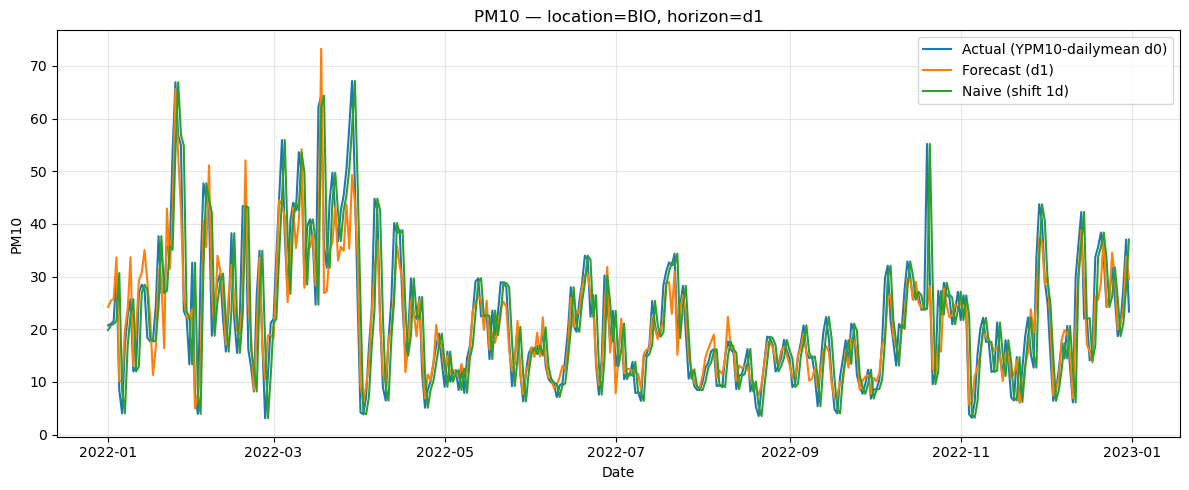

Example MAE model (loc=BIO, d1): 3.6201
Example MAE naive (loc=BIO, d1): 6.4108


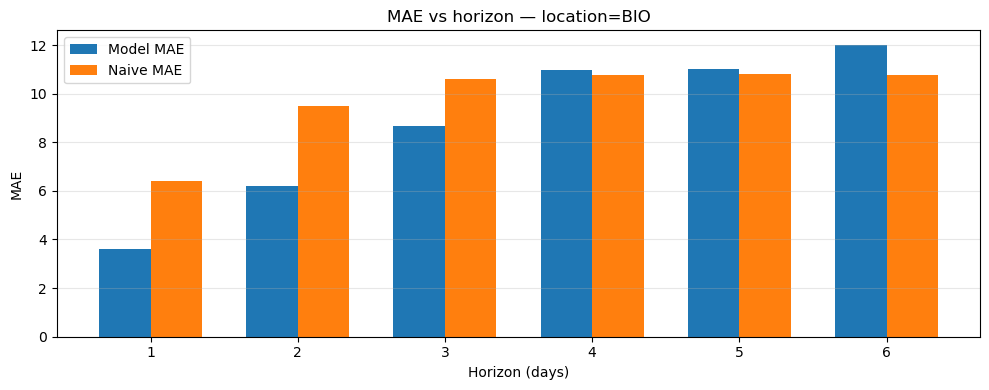

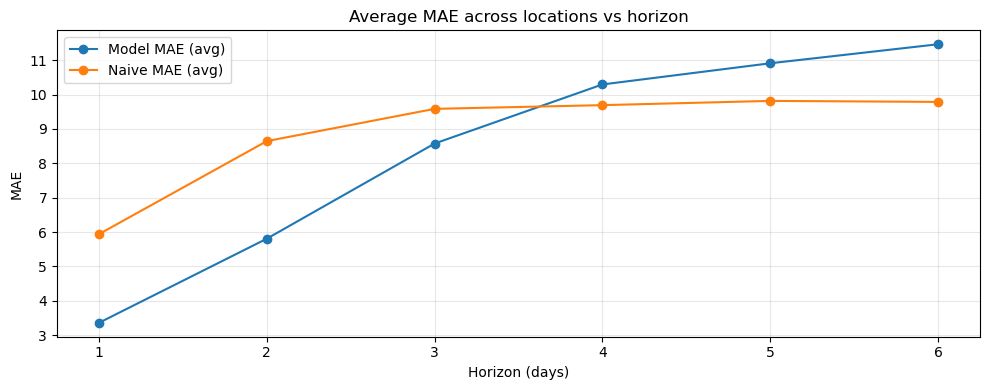

Average performance across all locations (by horizon):


,horizon,mae_model,mae_naive,avg_gain
0,1,3.357824,5.938357,2.580533
1,2,5.805367,8.645594,2.840227
2,3,8.575339,9.584946,1.009606
3,4,10.295212,9.692697,-0.602515
4,5,10.911472,9.816588,-1.094884
5,6,11.464936,9.787113,-1.677823


In [ ]:
# Visualization-only (correct ground truth: YPM10-dailymean__d0)
# No training, runs fast


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# A) Build TRUE actual series from YPM10-dailymean__d0
y_cols = [c for c in df_raw.columns if c.endswith("__YPM10-dailymean__d0")]
if not y_cols:
    raise ValueError("No columns ending with '__YPM10-dailymean__d0' found in df_raw.")

actual_frames = []
for col in y_cols:
    loc = col.split("__")[0]  # BIO, BRI, CHI, ...
    tmp = df_raw[['date', col]].copy()
    tmp = tmp.rename(columns={col: 'y'})
    tmp['location'] = loc
    actual_frames.append(tmp[['date', 'location', 'y']])

df_long = pd.concat(actual_frames, ignore_index=True)
df_long = df_long.dropna(subset=['y']).sort_values(['location', 'date'])

print("Actual (truth) built:", df_long.shape)
print("Locations (actual):", sorted(df_long['location'].unique())[:20], "...")
print("Date range:", df_long['date'].min().date(), "to", df_long['date'].max().date())

# B) Reshape forecasts: BIO__pred__d1 -> location=BIO, horizon=1
pred_cols = [c for c in f_raw.columns if "__pred__d" in c]
if not pred_cols:
    raise ValueError("No forecast columns like 'BIO__pred__d1' found in f_raw.")

f_pred = f_raw[['date'] + pred_cols].copy()
f_long = f_pred.melt(id_vars=['date'], var_name='col', value_name='y_pred').dropna(subset=['y_pred'])

parts = f_long['col'].str.split("__pred__d", n=1, expand=True)
forecasts_df = pd.DataFrame({
    "date": f_long["date"],
    "location": parts[0],
    "horizon": parts[1].astype(int),
    "y_pred": f_long["y_pred"]
})

horizons = sorted(forecasts_df['horizon'].unique())
common_locs = sorted(set(df_long['location'].unique()).intersection(set(forecasts_df['location'].unique())))

print("Forecasts reshaped:", forecasts_df.shape)
print("Horizons:", horizons)
print("Common locations:", common_locs)

if not common_locs:
    raise ValueError("No common location codes between truth and forecasts.")

# C) Naive baseline from truth: y(t) = y(t-h)
df_naive = df_long.copy()
for h in horizons:
    df_naive[f'naive_h{h}'] = df_naive.groupby('location')['y'].shift(h)

def mae(a, b):
    a = np.asarray(a); b = np.asarray(b)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.mean(np.abs(a[m] - b[m]))) if m.sum() else np.nan

def get_eval(loc, h):
    y_loc = df_long[df_long['location'] == loc][['date', 'y']]
    f_loc = forecasts_df[(forecasts_df['location'] == loc) & (forecasts_df['horizon'] == h)][['date', 'y_pred']]
    n_loc = df_naive[df_naive['location'] == loc][['date', f'naive_h{h}']].rename(columns={f'naive_h{h}': 'y_naive'})
    out = y_loc.merge(f_loc, on='date', how='inner').merge(n_loc, on='date', how='left')
    out = out.dropna(subset=['y', 'y_pred'])
    return out.sort_values('date')

# Plot 1: one location, one horizon
example_loc = common_locs[0]
example_h = horizons[0]
ev = get_eval(example_loc, example_h)

plt.figure(figsize=(12, 5))
plt.plot(ev['date'], ev['y'], label='Actual (YPM10-dailymean d0)')
plt.plot(ev['date'], ev['y_pred'], label=f'Forecast (d{example_h})')
if ev['y_naive'].notna().any():
    plt.plot(ev['date'], ev['y_naive'], label=f'Naive (shift {example_h}d)')
plt.title(f"PM10 — location={example_loc}, horizon=d{example_h}")
plt.xlabel("Date")
plt.ylabel("PM10")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Example MAE model (loc={example_loc}, d{example_h}): {mae(ev['y'], ev['y_pred']):.4f}")
print(f"Example MAE naive (loc={example_loc}, d{example_h}): {mae(ev['y'], ev['y_naive']):.4f}")

# Plot 2: MAE vs horizon for one location
rows = []
for h in horizons:
    evh = get_eval(example_loc, h)
    rows.append({"horizon": h, "mae_model": mae(evh['y'], evh['y_pred']), "mae_naive": mae(evh['y'], evh['y_naive'])})
mae_loc = pd.DataFrame(rows).sort_values('horizon')

x = np.arange(len(mae_loc)); w = 0.35
plt.figure(figsize=(10, 4))
plt.bar(x - w/2, mae_loc['mae_model'], width=w, label='Model MAE')
plt.bar(x + w/2, mae_loc['mae_naive'], width=w, label='Naive MAE')
plt.xticks(x, mae_loc['horizon'])
plt.title(f"MAE vs horizon — location={example_loc}")
plt.xlabel("Horizon (days)")
plt.ylabel("MAE")
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: average MAE across all locations vs horizon
all_rows = []
for loc in common_locs:
    for h in horizons:
        evh = get_eval(loc, h)
        all_rows.append({"location": loc, "horizon": h,
                         "mae_model": mae(evh['y'], evh['y_pred']),
                         "mae_naive": mae(evh['y'], evh['y_naive'])})
mae_all = pd.DataFrame(all_rows)

avg_by_h = (mae_all.groupby('horizon', as_index=False)[['mae_model', 'mae_naive']]
            .mean().sort_values('horizon'))

plt.figure(figsize=(10, 4))
plt.plot(avg_by_h['horizon'], avg_by_h['mae_model'], marker='o', label='Model MAE (avg)')
plt.plot(avg_by_h['horizon'], avg_by_h['mae_naive'], marker='o', label='Naive MAE (avg)')
plt.title("Average MAE across locations vs horizon")
plt.xlabel("Horizon (days)")
plt.ylabel("MAE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mae_all['gain_vs_naive'] = mae_all['mae_naive'] - mae_all['mae_model']
summary = (mae_all.groupby('horizon', as_index=False)
           .agg(mae_model=('mae_model','mean'),
                mae_naive=('mae_naive','mean'),
                avg_gain=('gain_vs_naive','mean'))
           .sort_values('horizon'))

print("Average performance across all locations (by horizon):")
display(summary)


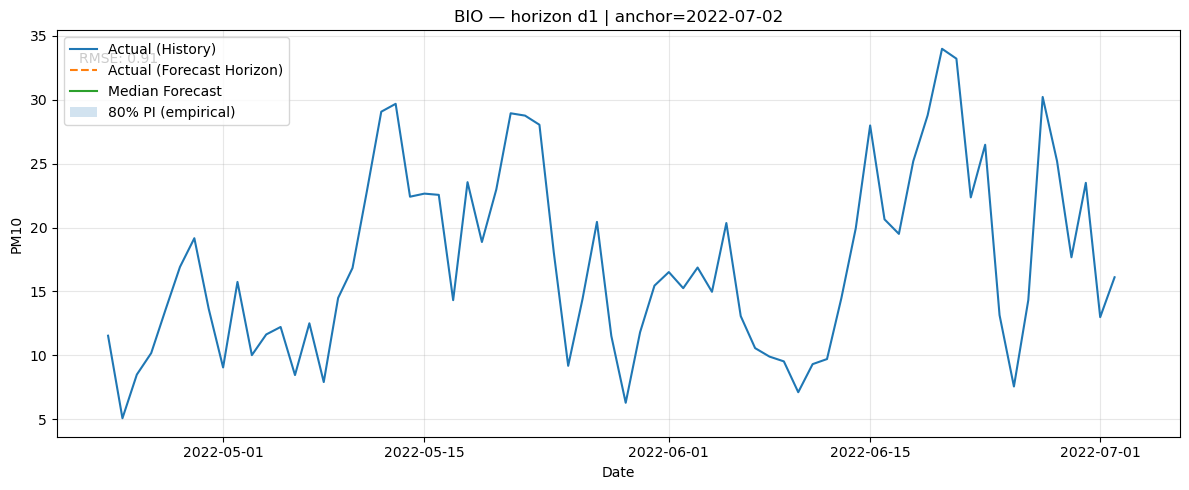

In [ ]:
# Cell A) Prof-style plot: history + forecast horizon + approx PI
# Requires: df_long (truth), forecasts_df (date, location, horizon, y_pred)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# configuration 
location = "BIO"        # change to any: BIO, BRI, CHI, GIU, LOC, LUG, MEN, NA-MAG
horizon = 1             # 1..6
anchor_date = None      # e.g. "2020-11-24" or None to auto-pick a valid date
history_days = 70       # how many days of history to show before anchor
pi_alpha = 0.20         # 80% PI => alpha=0.20

# build aligned frame for this location/horizon
y_loc = df_long[df_long["location"] == location][["date", "y"]].sort_values("date").copy()
f_loc = forecasts_df[(forecasts_df["location"] == location) & (forecasts_df["horizon"] == horizon)][["date", "y_pred"]].sort_values("date").copy()

# merge on date to ensure we only plot where we have forecast
ev = y_loc.merge(f_loc, on="date", how="inner").sort_values("date").reset_index(drop=True)
if ev.empty:
    raise ValueError(f"No overlapping dates for location={location} horizon={horizon}")

# choose anchor_date
if anchor_date is None:
    # pick a date not too early so we can show history
    anchor_idx = min(len(ev) - (horizon + 5), max(0, len(ev)//2))
    anchor_date = ev.loc[anchor_idx, "date"]
else:
    anchor_date = pd.to_datetime(anchor_date)

# window: history + forecast horizon block
start = anchor_date - pd.Timedelta(days=history_days)
end = anchor_date + pd.Timedelta(days=horizon)

# split into history and horizon window
hist = y_loc[(y_loc["date"] >= start) & (y_loc["date"] <= anchor_date)].copy()
horz = y_loc[(y_loc["date"] > anchor_date) & (y_loc["date"] <= end)].copy()

# model forecast values within (anchor_date, end]
f_window = f_loc[(f_loc["date"] > anchor_date) & (f_loc["date"] <= end)].copy()

# approximate PI using residuals for this horizon/location (empirical quantiles)
# residuals from all available dates (same location & horizon)
res = (ev["y"] - ev["y_pred"]).dropna().values
if len(res) > 20:
    lo_q = np.quantile(res, pi_alpha/2)
    hi_q = np.quantile(res, 1 - pi_alpha/2)
else:
    # fallback if too few points
    s = np.nanstd(res) if len(res) else 1.0
    lo_q, hi_q = -1.28*s, 1.28*s  # approx 80%

# PI around forecast: y_pred + [lo_q, hi_q]
f_window = f_window.copy()
f_window["pi_low"] = f_window["y_pred"] + lo_q
f_window["pi_high"] = f_window["y_pred"] + hi_q

# RMSE on the forecast horizon window (if we have actuals there)
rmse = np.nan
if not horz.empty and not f_window.empty:
    tmp = horz.merge(f_window[["date", "y_pred"]], on="date", how="inner")
    if len(tmp):
        rmse = float(np.sqrt(np.mean((tmp["y"] - tmp["y_pred"])**2)))

# plot 
plt.figure(figsize=(12, 5))

# Actual history (solid)
plt.plot(hist["date"], hist["y"], label="Actual (History)")

# Actual on forecast horizon (dashed)
if not horz.empty:
    plt.plot(horz["date"], horz["y"], linestyle="--", label="Actual (Forecast Horizon)")

# Median forecast (green)
if not f_window.empty:
    plt.plot(f_window["date"], f_window["y_pred"], label="Median Forecast")

# Prediction interval shading
if not f_window.empty:
    plt.fill_between(f_window["date"], f_window["pi_low"], f_window["pi_high"], alpha=0.2, label="80% PI (empirical)")

title = f"{location} — horizon d{horizon} | anchor={anchor_date.date()}"
plt.title(title)
plt.xlabel("Date")
plt.ylabel("PM10")
plt.grid(True, alpha=0.3)
plt.legend()

# annotate RMSE
if np.isfinite(rmse):
    plt.text(0.02, 0.92, f"RMSE: {rmse:.2f}", transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()


# Cell B modified

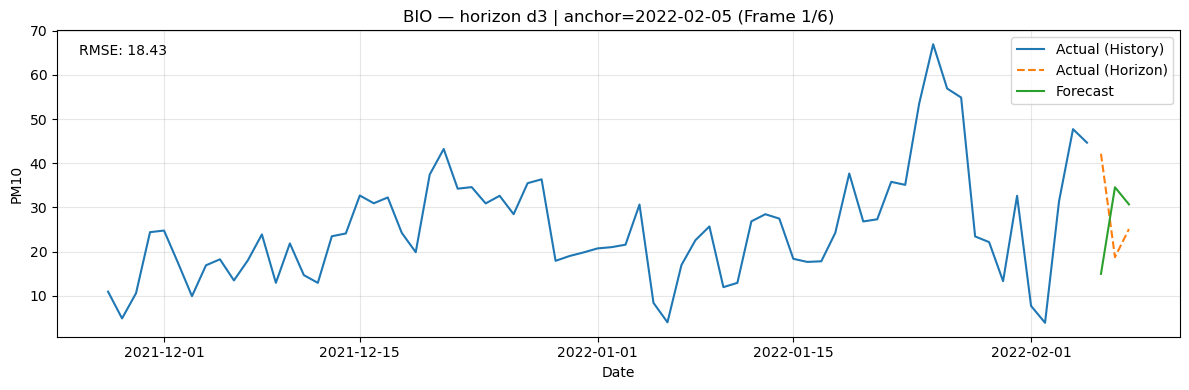

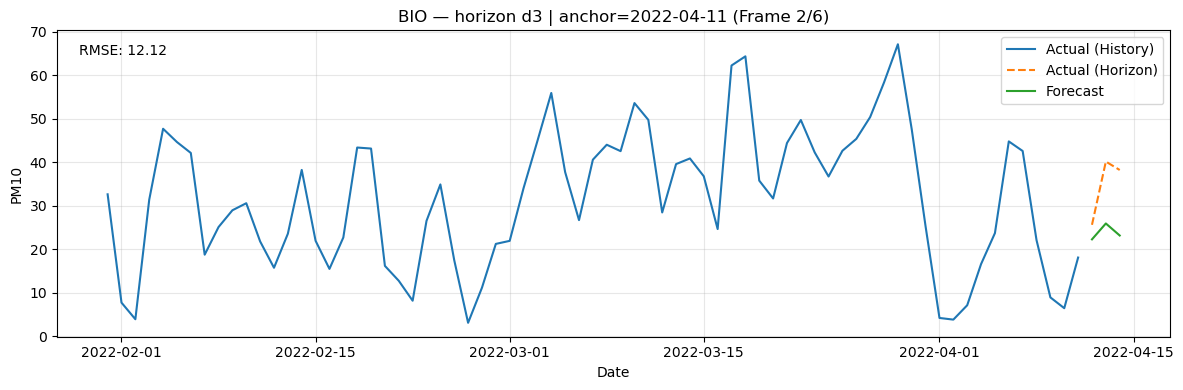

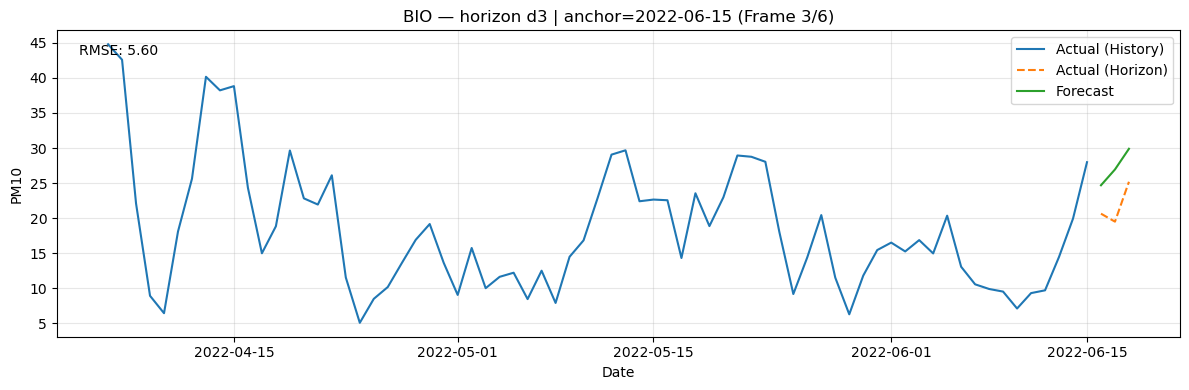

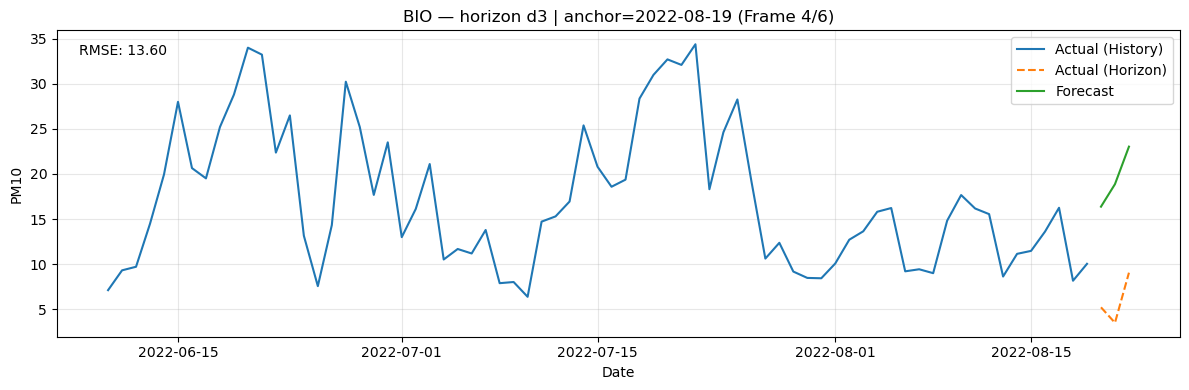

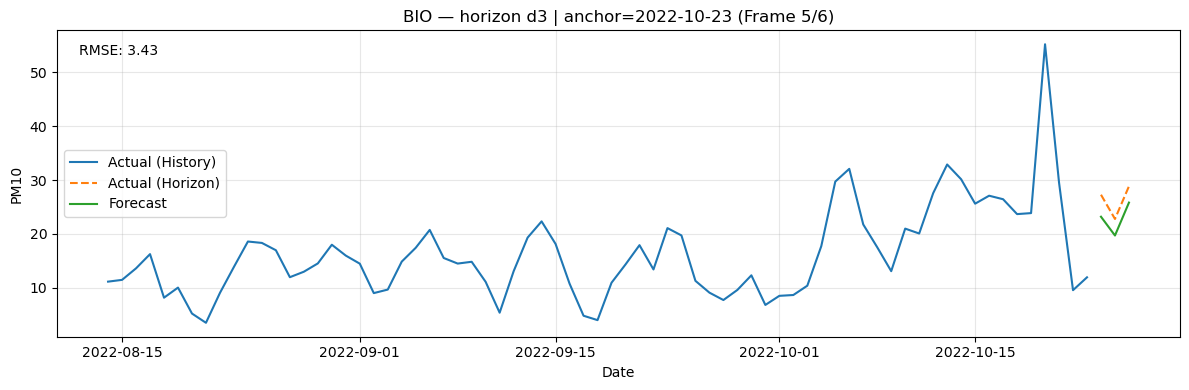

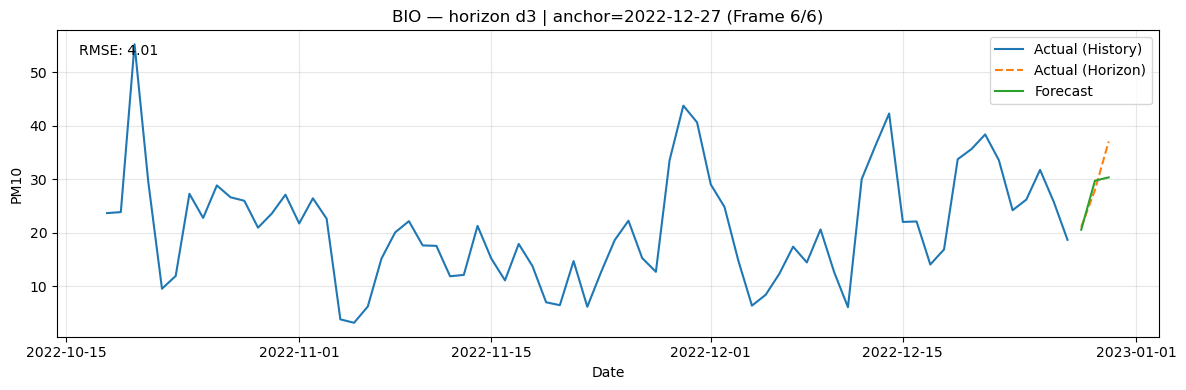

In [ ]:
# Cell B) Many frames (prof-style) — FIXED (no gaps)
# Shows: history (solid) + actual horizon (dashed) + forecast (green)
# Requires: df_long (date, location, y), forecasts_df (date, location, horizon, y_pred)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# user settings
location = "BIO"     # BIO, BRI, CHI, GIU, LOC, LUG, MEN, NA-MAG, ...
horizon = 3          # 1..6
history_days = 70    # days shown before anchor
n_frames = 6         # how many frames to show
show_rmse = True     # annotate RMSE on the horizon window

# prepare aligned data (only dates where actual + forecast exist)
y_loc = (df_long[df_long["location"] == location][["date", "y"]]
         .dropna()
         .sort_values("date")
         .copy())

f_loc = (forecasts_df[(forecasts_df["location"] == location) & (forecasts_df["horizon"] == horizon)][["date", "y_pred"]]
         .dropna()
         .sort_values("date")
         .copy())

ev = (y_loc.merge(f_loc, on="date", how="inner")
      .dropna()
      .sort_values("date")
      .reset_index(drop=True))

if ev.empty:
    raise ValueError(f"No aligned dates for location={location}, horizon=d{horizon}.")
if len(ev) < 30:
    raise ValueError(f"Too few aligned points ({len(ev)}) to create frames.")

# choose anchor indices from aligned dates to guarantee continuity 
# Keep anchors away from the end so we can display the horizon window.
max_anchor_idx = len(ev) - 5
min_anchor_idx = max(5, history_days // 2)  # safe-ish start

if max_anchor_idx <= min_anchor_idx:
    min_anchor_idx = 5
    max_anchor_idx = len(ev) - 5

idxs = np.linspace(min_anchor_idx, max_anchor_idx, n_frames).astype(int)

# plotting loop 
for i, idx in enumerate(idxs, start=1):
    anchor_date = ev.loc[idx, "date"]

    # history window: last history point is guaranteed to exist
    start = anchor_date - pd.Timedelta(days=history_days)
    hist = y_loc[(y_loc["date"] >= start) & (y_loc["date"] <= anchor_date)].copy()

    if hist.empty:
        # extremely unlikely, but safe
        continue

    # IMPORTANT FIX: split at the last actual history date, not an arbitrary calendar day
    last_hist_date = hist["date"].max()

    # horizon range (calendar-based end, but we use available dates inside that window)
    end = last_hist_date + pd.Timedelta(days=horizon)

    # actual values within the horizon window
    horz = y_loc[(y_loc["date"] > last_hist_date) & (y_loc["date"] <= end)].copy()

    # forecast values within the horizon window
    f_window = f_loc[(f_loc["date"] > last_hist_date) & (f_loc["date"] <= end)].copy()

    # compute RMSE on the plotted horizon window (only where both exist)
    rmse = np.nan
    if show_rmse and (not horz.empty) and (not f_window.empty):
        tmp = horz.merge(f_window, on="date", how="inner")
        if len(tmp):
            rmse = float(np.sqrt(np.mean((tmp["y"] - tmp["y_pred"]) ** 2)))

    # plot
    plt.figure(figsize=(12, 4))

    plt.plot(hist["date"], hist["y"], label="Actual (History)")

    if not horz.empty:
        plt.plot(horz["date"], horz["y"], linestyle="--", label="Actual (Horizon)")

    if not f_window.empty:
        plt.plot(f_window["date"], f_window["y_pred"], label="Forecast")

    plt.title(f"{location} — horizon d{horizon} | anchor={anchor_date.date()} (Frame {i}/{n_frames})")
    plt.xlabel("Date")
    plt.ylabel("PM10")
    plt.grid(True, alpha=0.3)
    plt.legend()

    if show_rmse and np.isfinite(rmse):
        plt.text(0.02, 0.92, f"RMSE: {rmse:.2f}", transform=plt.gca().transAxes)

    plt.tight_layout()
    plt.show()


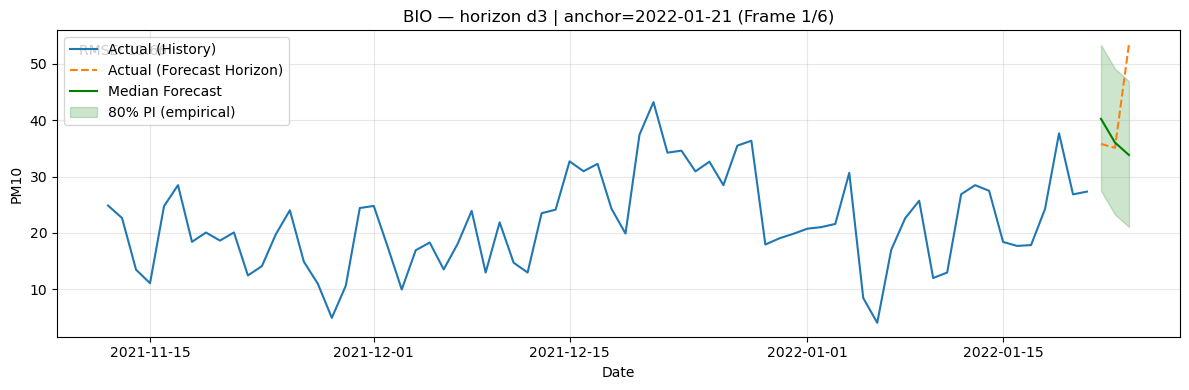

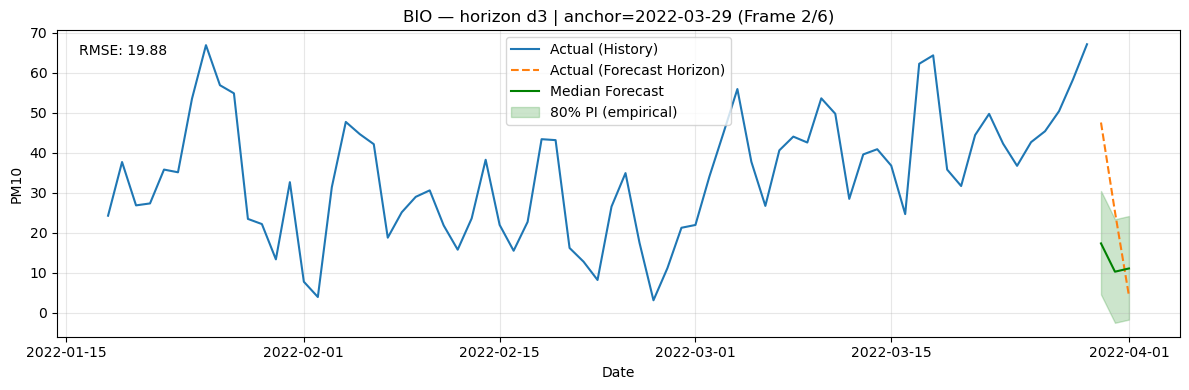

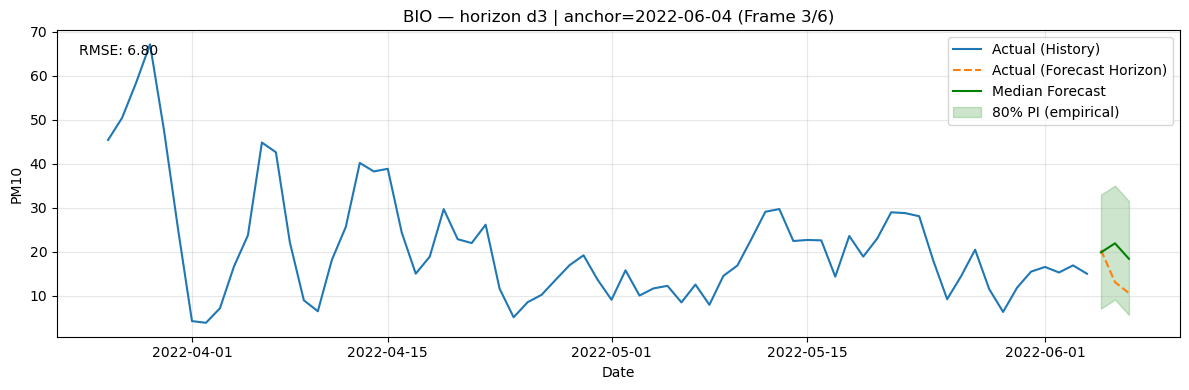

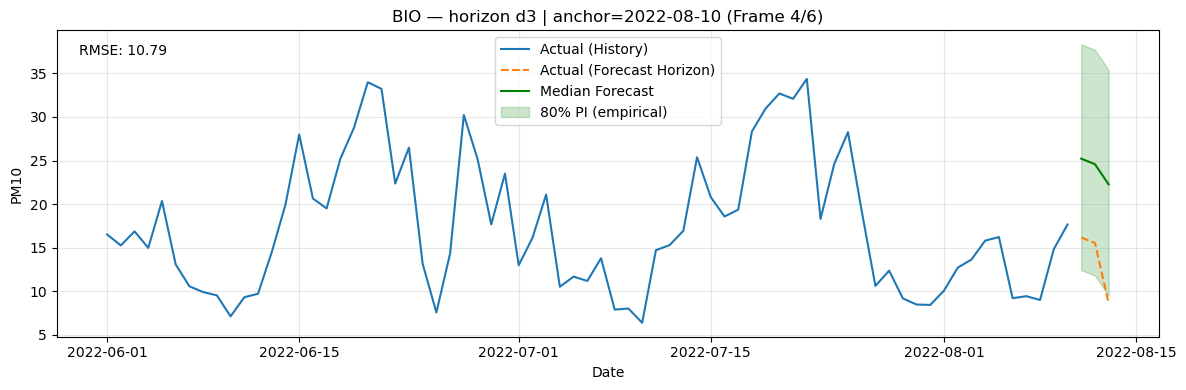

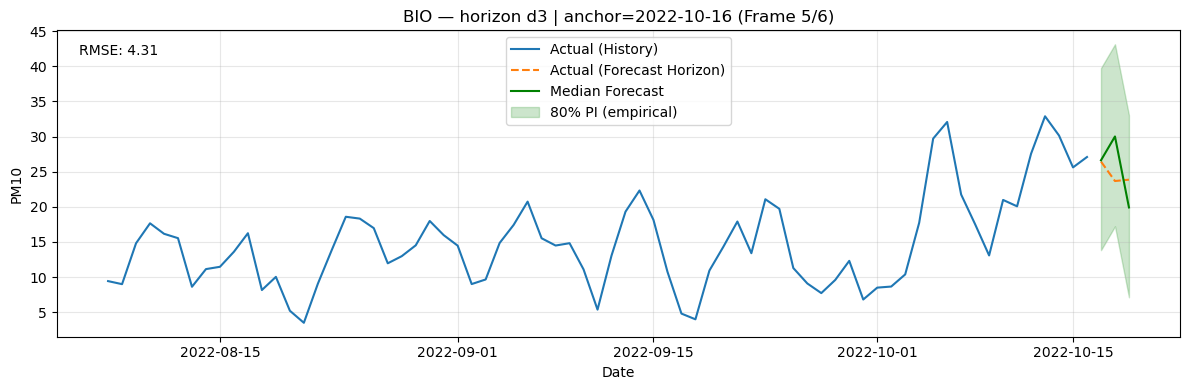

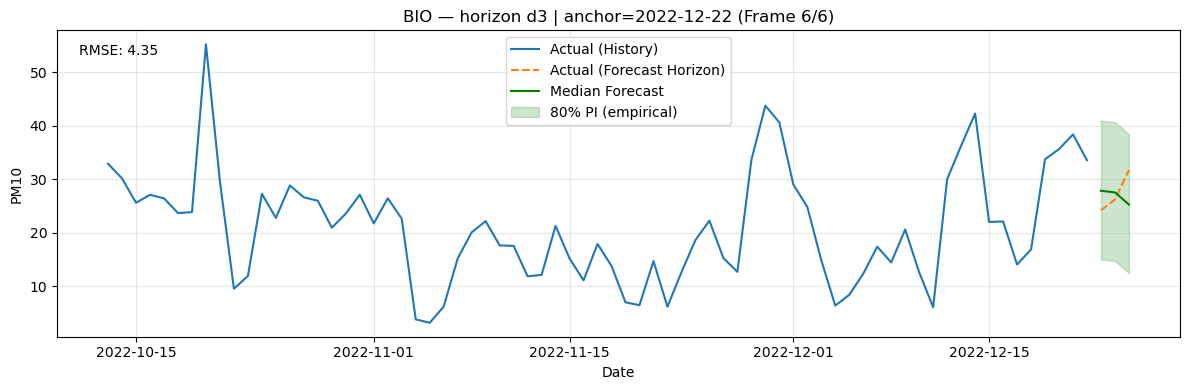

In [ ]:
# Cell B) Many frames (prof-style) — ORIGINAL STYLE (keeps gaps) + 80% PI
# Requires: df_long (date, location, y), forecasts_df (date, location, horizon, y_pred)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# settings
location = "BIO"
horizon = 3
history_days = 70
n_frames = 6
pi_alpha = 0.20     # 80% PI
show_rmse = True

# series
y_loc = (df_long[df_long["location"] == location][["date", "y"]]
         .dropna()
         .sort_values("date")
         .copy())

f_loc = (forecasts_df[(forecasts_df["location"] == location) &
                      (forecasts_df["horizon"] == horizon)][["date", "y_pred"]]
         .dropna()
         .sort_values("date")
         .copy())

# aligned residuals (same loc+h) used to compute empirical PI
ev_all = (y_loc.merge(f_loc, on="date", how="inner")
          .dropna()
          .sort_values("date")
          .reset_index(drop=True))

if len(ev_all) < 40:
    raise ValueError("Not enough aligned points to create frames / PI.")

residuals = (ev_all["y"] - ev_all["y_pred"]).values
if len(residuals) > 20:
    q_low = np.quantile(residuals, pi_alpha / 2)
    q_high = np.quantile(residuals, 1 - pi_alpha / 2)
else:
    s = np.nanstd(residuals)
    q_low, q_high = -1.28 * s, 1.28 * s  # approx 80%

# choose evenly spaced anchor indices from aligned dates
idxs = np.linspace(20, len(ev_all) - 10, n_frames).astype(int)

for i, idx in enumerate(idxs, start=1):
    anchor_date = ev_all.loc[idx, "date"]

    # ORIGINAL STYLE: split by anchor_date directly (this is what causes gaps)
    start = anchor_date - pd.Timedelta(days=history_days)
    end = anchor_date + pd.Timedelta(days=horizon)

    hist = y_loc[(y_loc["date"] >= start) & (y_loc["date"] <= anchor_date)].copy()
    horz = y_loc[(y_loc["date"] > anchor_date) & (y_loc["date"] <= end)].copy()

    f_window = f_loc[(f_loc["date"] > anchor_date) & (f_loc["date"] <= end)].copy()
    if not f_window.empty:
        f_window = f_window.copy()
        f_window["pi_low"] = f_window["y_pred"] + q_low
        f_window["pi_high"] = f_window["y_pred"] + q_high

    # RMSE on plotted horizon dates
    rmse = np.nan
    if show_rmse and (not horz.empty) and (not f_window.empty):
        tmp = horz.merge(f_window[["date", "y_pred"]], on="date", how="inner")
        if len(tmp):
            rmse = float(np.sqrt(np.mean((tmp["y"] - tmp["y_pred"]) ** 2)))

    # plot
    plt.figure(figsize=(12, 4))
    plt.plot(hist["date"], hist["y"], label="Actual (History)")

    if not horz.empty:
        plt.plot(horz["date"], horz["y"], linestyle="--", label="Actual (Forecast Horizon)")

    if not f_window.empty:
        plt.plot(f_window["date"], f_window["y_pred"], color="green", label="Median Forecast")
        plt.fill_between(
            f_window["date"],
            f_window["pi_low"],
            f_window["pi_high"],
            color="green",
            alpha=0.2,
            label="80% PI (empirical)"
        )

    plt.title(f"{location} — horizon d{horizon} | anchor={anchor_date.date()} (Frame {i}/{n_frames})")
    plt.xlabel("Date")
    plt.ylabel("PM10")
    plt.grid(True, alpha=0.3)
    plt.legend()

    if show_rmse and np.isfinite(rmse):
        plt.text(0.02, 0.92, f"RMSE: {rmse:.2f}", transform=plt.gca().transAxes)

    plt.tight_layout()
    plt.show()


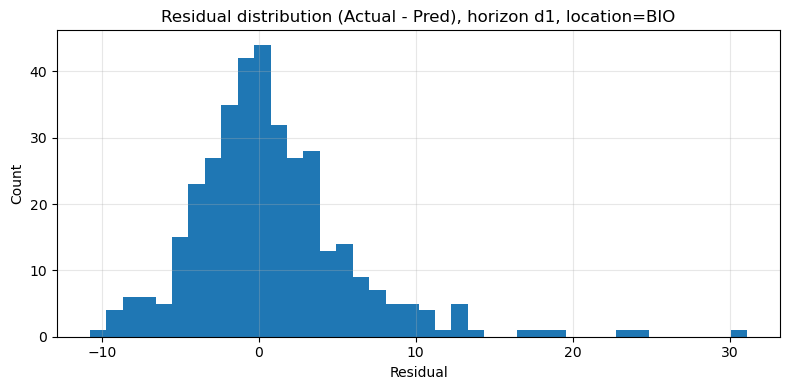

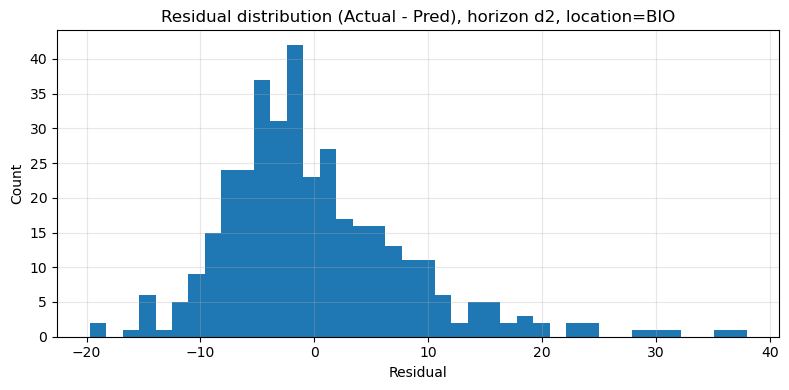

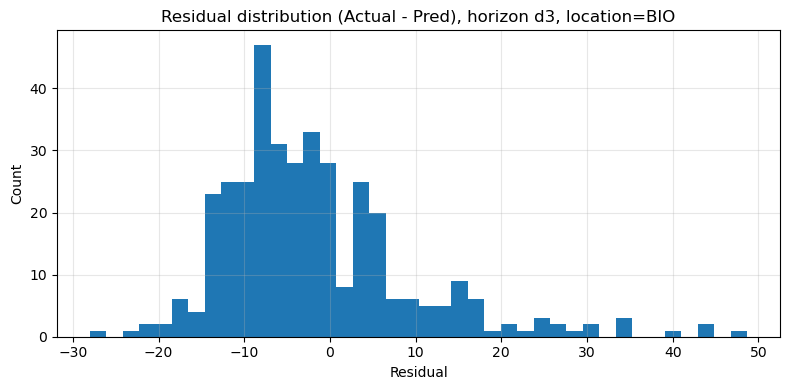

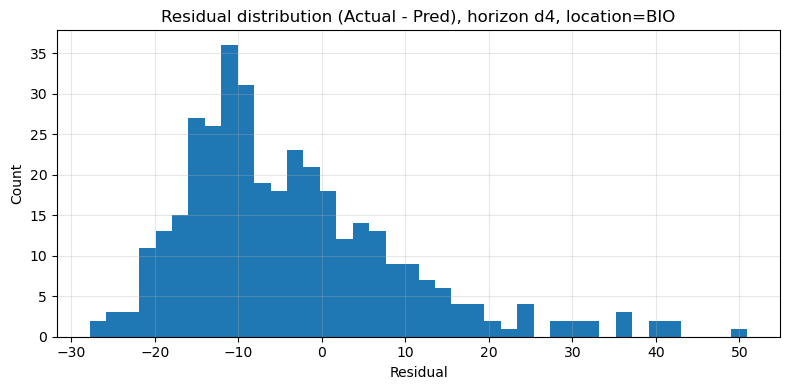

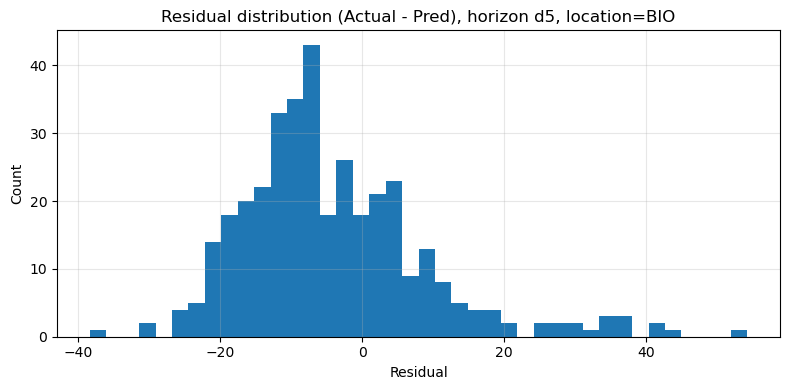

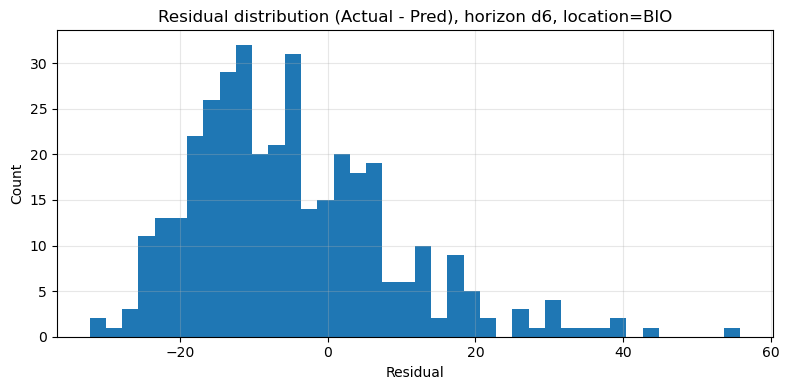

In [ ]:
# Cell C) Residual diagnostics: histogram per horizon


import numpy as np
import matplotlib.pyplot as plt

location = "BIO"   # or None for all locations

def get_residuals(loc, h):
    y = df_long[df_long["location"] == loc][["date","y"]]
    f = forecasts_df[(forecasts_df["location"] == loc) & (forecasts_df["horizon"] == h)][["date","y_pred"]]
    ev = y.merge(f, on="date", how="inner").dropna()
    return (ev["y"] - ev["y_pred"]).values

locs = [location] if location is not None else sorted(df_long["location"].unique())
horizons = sorted(forecasts_df["horizon"].unique())

for h in horizons:
    # pool residuals across chosen locations
    res_all = []
    for loc in locs:
        r = get_residuals(loc, h)
        if len(r):
            res_all.append(r)
    if not res_all:
        continue
    res = np.concatenate(res_all)

    plt.figure(figsize=(8, 4))
    plt.hist(res, bins=40)
    plt.title(f"Residual distribution (Actual - Pred), horizon d{h}" + (f", location={location}" if location else ", all locations"))
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


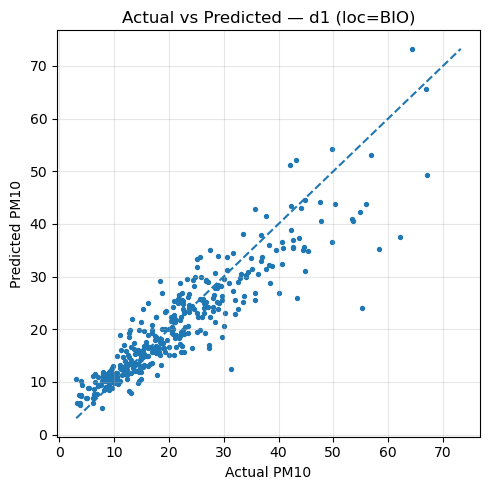

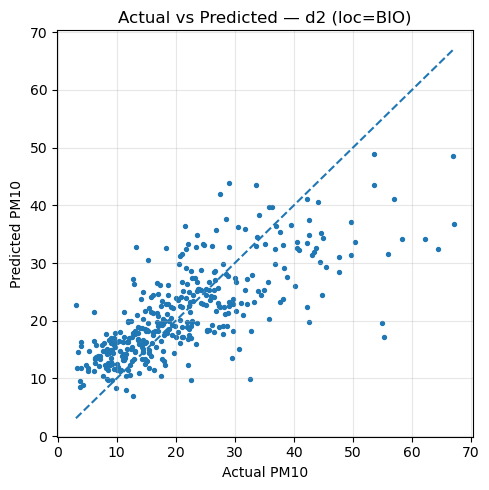

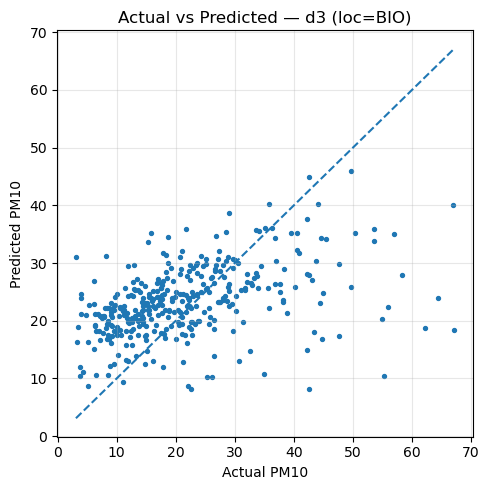

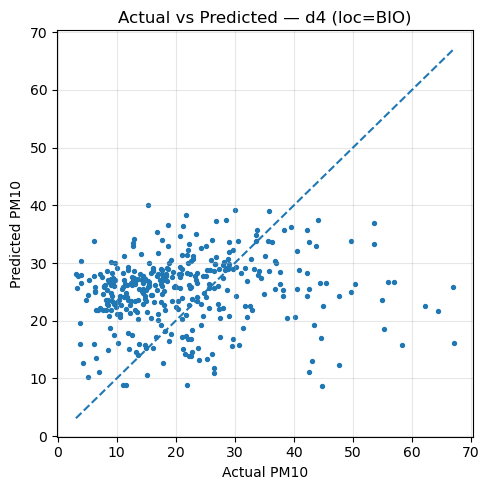

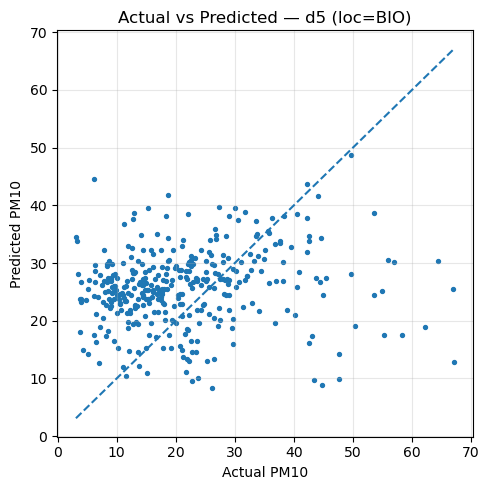

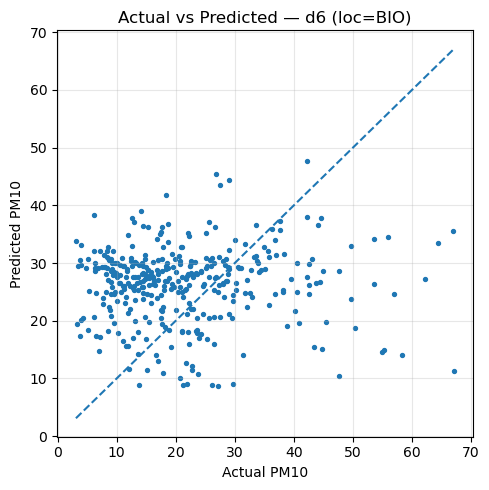

In [ ]:
# Cell D) Scatter: Actual vs Predicted (by horizon)


import matplotlib.pyplot as plt
import numpy as np

location = "BIO"   # set None to pool all locations

def get_eval(loc, h):
    y = df_long[df_long["location"] == loc][["date","y"]]
    f = forecasts_df[(forecasts_df["location"] == loc) & (forecasts_df["horizon"] == h)][["date","y_pred"]]
    return y.merge(f, on="date", how="inner").dropna()

locs = [location] if location is not None else sorted(df_long["location"].unique())
horizons = sorted(forecasts_df["horizon"].unique())

for h in horizons:
    frames = []
    for loc in locs:
        frames.append(get_eval(loc, h))
    ev = pd.concat(frames, ignore_index=True)
    if ev.empty:
        continue

    plt.figure(figsize=(5, 5))
    plt.scatter(ev["y"], ev["y_pred"], s=8)
    # y=x reference line
    mn = float(np.nanmin([ev["y"].min(), ev["y_pred"].min()]))
    mx = float(np.nanmax([ev["y"].max(), ev["y_pred"].max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--")

    plt.title(f"Actual vs Predicted — d{h}" + (f" (loc={location})" if location else " (all locs)"))
    plt.xlabel("Actual PM10")
    plt.ylabel("Predicted PM10")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


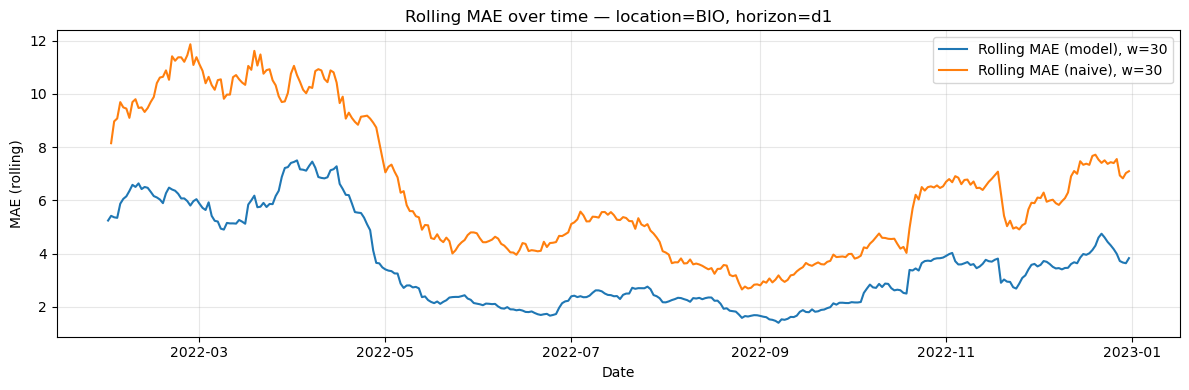

In [ ]:
# Cell E) Rolling MAE over time (model vs naive) — prof-friendly stability plot


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

location = "BIO"
horizon = 1
window = 30  # days

# build eval frame
y = df_long[df_long["location"] == location][["date","y"]]
f = forecasts_df[(forecasts_df["location"] == location) & (forecasts_df["horizon"] == horizon)][["date","y_pred"]]
ev = y.merge(f, on="date", how="inner").sort_values("date").dropna()

# naive
ev["y_naive"] = ev["y"].shift(horizon)

# errors
ev["abs_err_model"] = (ev["y"] - ev["y_pred"]).abs()
ev["abs_err_naive"] = (ev["y"] - ev["y_naive"]).abs()

# rolling mean absolute error
ev["roll_mae_model"] = ev["abs_err_model"].rolling(window).mean()
ev["roll_mae_naive"] = ev["abs_err_naive"].rolling(window).mean()

plt.figure(figsize=(12, 4))
plt.plot(ev["date"], ev["roll_mae_model"], label=f"Rolling MAE (model), w={window}")
plt.plot(ev["date"], ev["roll_mae_naive"], label=f"Rolling MAE (naive), w={window}")
plt.title(f"Rolling MAE over time — location={location}, horizon=d{horizon}")
plt.xlabel("Date")
plt.ylabel("MAE (rolling)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Cell B connected the points- no gap

# NOTE:
- To improve visual continuity and readability, a bridge point equal to the last
-  observed historical value is added at the forecast start date.
- This point is used for visualization purposes only and is NOT included in any
- error metrics (MAE, RMSE) or model evaluation.


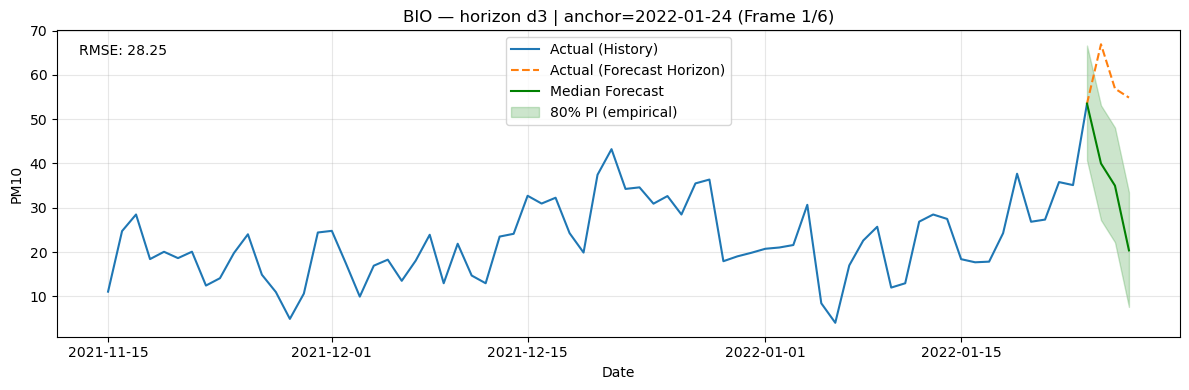

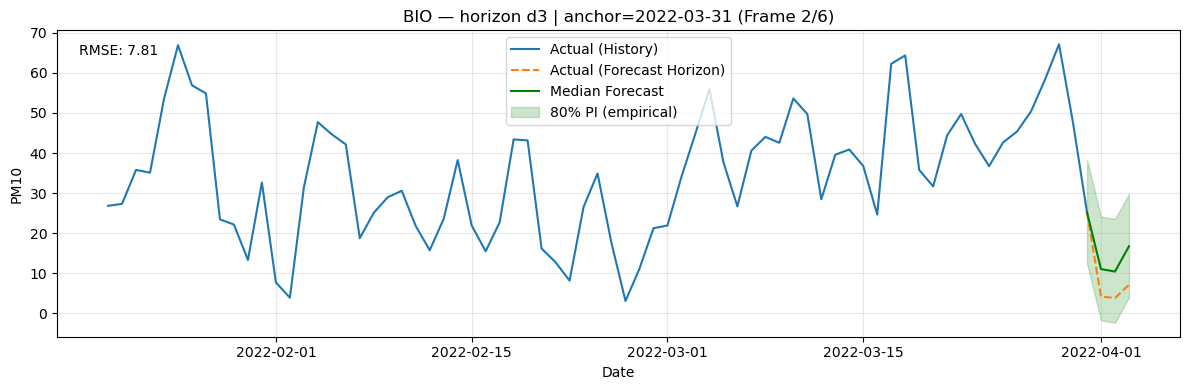

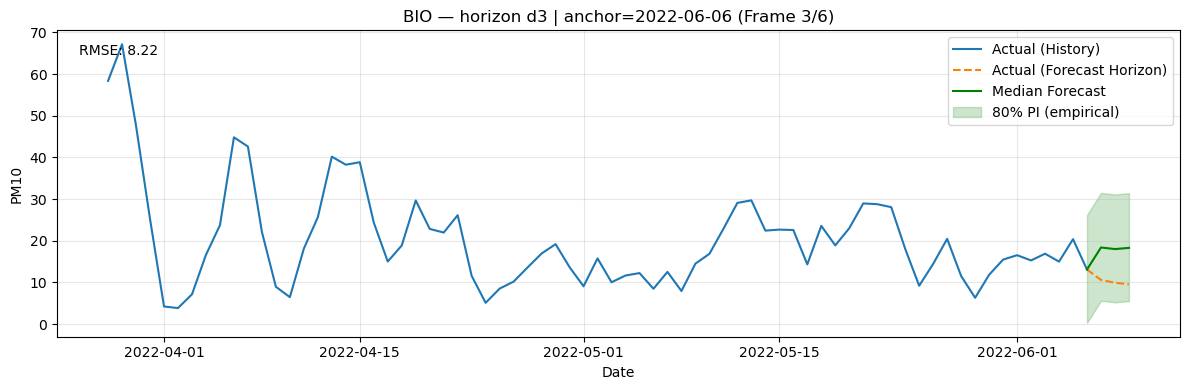

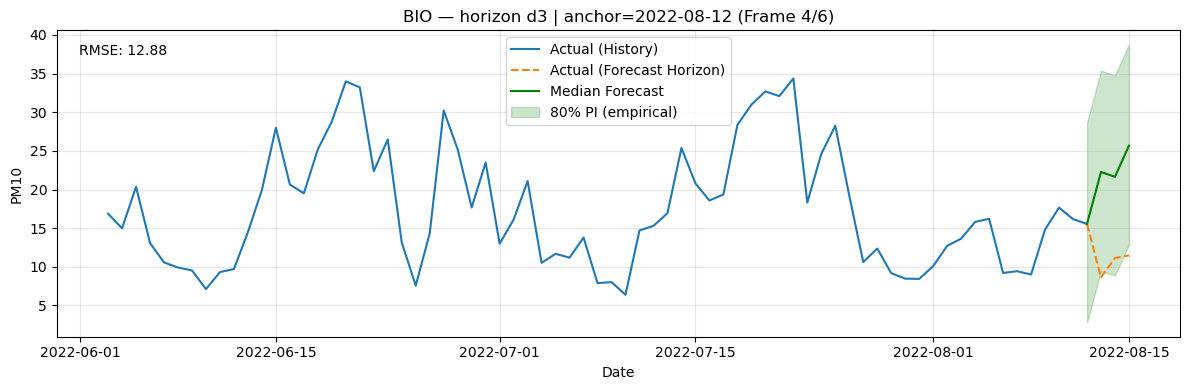

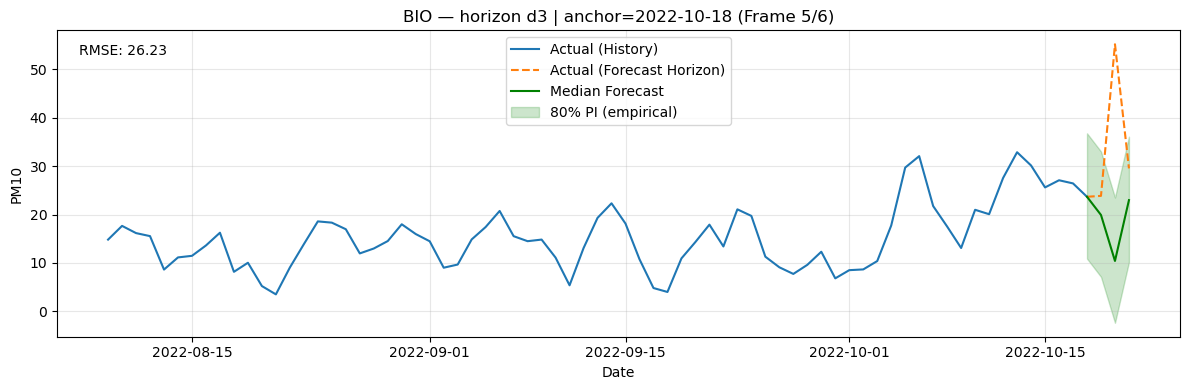

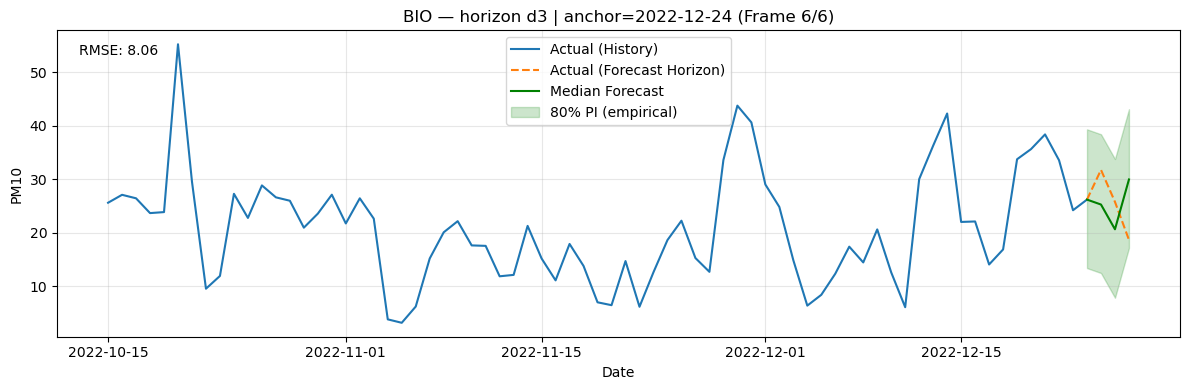

In [ ]:
# Cell B) Many frames (prof-style) — FIXED + 80% PI (empirical)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# user settings
location = "BIO"
horizon = 3
history_days = 70
n_frames = 6
pi_alpha = 0.20        # 80% PI
show_rmse = True

# aligned actual + forecast
y_loc = (df_long[df_long["location"] == location][["date", "y"]]
         .dropna()
         .sort_values("date")
         .copy())

f_loc = (forecasts_df[(forecasts_df["location"] == location) &
                      (forecasts_df["horizon"] == horizon)][["date", "y_pred"]]
         .dropna()
         .sort_values("date")
         .copy())

ev = (y_loc.merge(f_loc, on="date", how="inner")
      .dropna()
      .sort_values("date")
      .reset_index(drop=True))

if len(ev) < 40:
    raise ValueError("Not enough aligned data to build frames.")

# empirical residuals for PI (ALL dates, same loc+horizon)
residuals = (ev["y"] - ev["y_pred"]).values
if len(residuals) > 20:
    q_low = np.quantile(residuals, pi_alpha / 2)
    q_high = np.quantile(residuals, 1 - pi_alpha / 2)
else:
    # fallback if few samples
    s = np.nanstd(residuals)
    q_low, q_high = -1.28 * s, 1.28 * s  # approx 80%

# choose anchors safely
max_anchor_idx = len(ev) - (horizon + 5)
min_anchor_idx = max(10, history_days // 3)
idxs = np.linspace(min_anchor_idx, max_anchor_idx, n_frames).astype(int)

# plotting loop
for i, idx in enumerate(idxs, start=1):
    anchor_date = ev.loc[idx, "date"]

    # history
    start = anchor_date - pd.Timedelta(days=history_days)
    hist = y_loc[(y_loc["date"] >= start) & (y_loc["date"] <= anchor_date)].copy()
    if hist.empty:
        continue

    last_hist_date = hist["date"].max()
    last_hist_y = hist.loc[hist["date"] == last_hist_date, "y"].iloc[-1]

    # horizon window
    end = last_hist_date + pd.Timedelta(days=horizon)
    horz = y_loc[(y_loc["date"] > last_hist_date) & (y_loc["date"] <= end)].copy()
    f_window = f_loc[(f_loc["date"] > last_hist_date) & (f_loc["date"] <= end)].copy()

    # bridge points (visual continuity only)
    horz_plot = pd.concat(
        [pd.DataFrame({"date": [last_hist_date], "y": [last_hist_y]}), horz],
        ignore_index=True
    ).sort_values("date")

    f_plot = pd.concat(
        [pd.DataFrame({"date": [last_hist_date], "y_pred": [last_hist_y]}), f_window],
        ignore_index=True
    ).sort_values("date")

    # PI bounds (only for forecast part)
    f_plot["pi_low"] = f_plot["y_pred"] + q_low
    f_plot["pi_high"] = f_plot["y_pred"] + q_high

    # RMSE on true horizon (no bridge)
    rmse = np.nan
    if show_rmse and (not horz.empty) and (not f_window.empty):
        tmp = horz.merge(f_window, on="date", how="inner")
        if len(tmp):
            rmse = float(np.sqrt(np.mean((tmp["y"] - tmp["y_pred"]) ** 2)))

    # plot
    plt.figure(figsize=(12, 4))

    plt.plot(hist["date"], hist["y"], label="Actual (History)")
    plt.plot(horz_plot["date"], horz_plot["y"], linestyle="--", label="Actual (Forecast Horizon)")
    plt.plot(f_plot["date"], f_plot["y_pred"], color="green", label="Median Forecast")

    # PI shading (forecast part only)
    plt.fill_between(
        f_plot["date"],
        f_plot["pi_low"],
        f_plot["pi_high"],
        color="green",
        alpha=0.2,
        label="80% PI (empirical)"
    )

    plt.title(f"{location} — horizon d{horizon} | anchor={anchor_date.date()} (Frame {i}/{n_frames})")
    plt.xlabel("Date")
    plt.ylabel("PM10")
    plt.grid(True, alpha=0.3)
    plt.legend()

    if show_rmse and np.isfinite(rmse):
        plt.text(0.02, 0.92, f"RMSE: {rmse:.2f}", transform=plt.gca().transAxes)

    plt.tight_layout()
    plt.show()
